# Introduction to Scikit-Learn

> 🐍 The scikit-learn project is an open-source machine learning library for Python programming language.

Scikit-Learn is essentialy library-a collection of classes and functions- that users can import into their Python programs. The best part? You only need a base understanding of Python to get started.

## Key Features

Designed to integrate seamlessly with Python's powerful scientific computing ecosystem, scikit-learn works hand-in-hand with libraries like:
- 📊 NumPy
- 🧮 SciPy

This makes it an essential tool for anyone working in:
- 🔍 Data analysis
- 🤖 Machine learning
- 🔬 Scientific computing

### Licensing Details

The library is distributed under the simplified Berkeley Software Distribution (BSD) license.

> 💡 **BSD License**: A family of permissive open-source software licenses that allow for the redistribution of software with minimal restrictions.


## Core API

Application Programming Interface (API) refers to the set of functions, classes, and methods that allow Python programmers to communicate & interact with scikit-learn library.

All objects within scikit-learn share a uniform common basic API consisting of three complementary interfaces:

1. **Transformer Interface** for transforming data
2. **Estimator Interface** for building and fitting models
3. **Predictor Interface** for making predictions
---


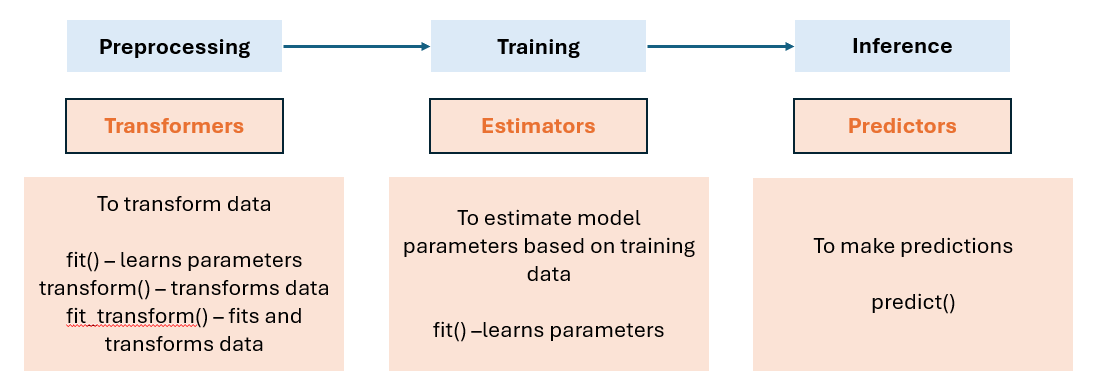

## Step 1: Let Us First Download Some Data 🌟


In [10]:
from sklearn.datasets import load_diabetes

# Load the dataset
diabetes = load_diabetes()

# # print description
print(diabetes.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

  :Number of Instances: 442

  :Number of Attributes: First 10 columns are numeric predictive values

  :Target: Column 11 is a quantitative measure of disease progression one year after baseline

  :Attribute Information:
      - age     age in years
      - sex
      - bmi     body mass index
      - bp      average blood pressure
      - s1      tc, total serum cholesterol
      - s2      ldl, low-density lipoproteins
      - s3      hdl, high-density lipoproteins
      - s4      tch, total cholesterol / HDL
      - s5      ltg, possibly log of serum triglycerides level
      - s6      glu, blood sugar level

Note: Each of these 1

In [2]:
# Look at the data as a dataframe
df = load_diabetes(as_frame=True)
df.frame.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019908,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068330,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005671,-0.045599,-0.034194,-0.032356,-0.002592,0.002864,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022692,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031991,-0.046641,135.0


$$
Linear Regression
$$


Equation:

$$
\mathbf{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n + \epsilon
$$

Where:

- **Dependent (response) variable:**  
  - $\mathbf{y}$ → the variable we want to predict or explain  

- **Independent (predictor) variables:**  
  - $x_1, x_2, \dots, x_n$ → the variables used to predict $y$  

- **Parameters (coefficients):**  
  - $\beta_0$ → intercept (value of $y$ when all $x_i = 0$)  
  - $\beta_1, \beta_2, \dots, \beta_n$ → coefficients

- **Error term:**  
  - $\epsilon$ → represents random error or unexplained variability in $y$


## Step 2: Create Train Test split 🌟

In [3]:
# Split the data into train & test
from sklearn.model_selection import train_test_split
import numpy as np
X = diabetes.data[:, np.newaxis, 2]  # take only BMI feature (index 2)
y = diabetes.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Step 3: Fit a linear regression model over the training set🌟

###

All supervised & unsupervised learning algorithms in scikit-learn are offered as objects implementing estimator interface. But that's not all! Even machine learning tasks like:

- 🔍 Feature extraction
- 🎯 Feature selection
- 📊 Dimensionality reduction

are provided as estimators.



In [4]:
# Example of the initialise-fit sequence
from sklearn.linear_model import LinearRegression

# Initialise the model
lin_reg = LinearRegression()

# Fit the model
lin_reg.fit(X_train, y_train)

LinearRegression()

## Step 4: Make predictions over the test set🌟

Key points:
- The `predict` method is called after the model has been trained using `fit()`.
- It uses the learned parameters to make predictions on new, unseen data.
- The input to `predict` should have the same format as the training data, but without the target variable.

In [5]:
# Predict
y_pred = lin_reg.predict(X_test)

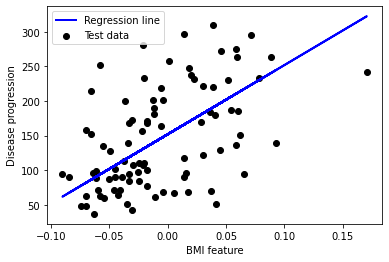

In [7]:
# Plot
import matplotlib.pyplot as plt
%matplotlib inline

plt.scatter(X_test, y_test, color="black", label="Test data")
plt.plot(X_test, y_pred, color="blue", linewidth=2, label="Regression line")
plt.xlabel("BMI feature")
plt.ylabel("Disease progression")
plt.legend()
plt.show()


## Step 5: Lets evaluate our model🌟

### Evaluation Metrics in Machine Learning

> 📊 Evaluation metrics are quantitative measures used to assess the performance and effectiveness of a statistical or machine learning model.

These metrics provide crucial insights:
- 🎯 How well the model is performing
- 🔄 Comparing different models or algorithms

#### 📐 Regression Metric: Mean Squared Error (MSE)  

The **Mean Squared Error (MSE)** measures the average squared difference between the actual values $(y_i)$ and the predicted values $(\hat{y}_i$).  

$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$  

Where:  
- $n$ = number of samples  
- $y_i$ = actual value for the $i^{th}$ sample  
- $\hat{y}_i$ = predicted value for the $i^{th}$ sample  

✅ Lower MSE means better model performance.

In [8]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 4061.825928494928


## Step 6: Reiterate after adding all features 🌟

In [9]:
from sklearn import datasets, linear_model
from sklearn.model_selection import train_test_split

# Load dataset
diabetes = datasets.load_diabetes()



# Split train/test
X_train, X_test, y_train, y_test = train_test_split(df.data, df.target, test_size=0.2, random_state=42)


# Fit regression
lin_reg = linear_model.LinearRegression()
lin_reg.fit(X_train, y_train)

# Predict
y_pred = lin_reg.predict(X_test)

from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)




MSE: 2900.173287883232
